# Tanager Mangrove Mapping - 03 Transferability

| | |
|---|---|
| **Authors**     | Muhammad Wahyu Ramadhan, Athar Abdurrahman B., Diniyarti |
| **Competition** | Planet Tanager Open Data Competition 2026 |
| **Topic**       | Transferable Mangrove Extent and Biomass Mapping Using Adaptive Spectral Thresholds |
| **Date**        | June 2026 |

---

**Scope:** Apply pipeline trained on Sangatta to Gujarat, El Salvador, Belize, Australia. Per-scene adaptive threshold recalibration — no retraining. Accuracy evaluation against GMW v3.

## 0. Environment Setup

In [1]:
!pip install scikit-learn geopandas rasterio matplotlib joblib xgboost


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import sys
import json
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio

# ============================================================
# Project root
# ============================================================
# Google Colab (Google Drive mounted)
ROOT        = Path('/content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping')

# Local (uncomment if running locally)
# ROOT = Path('..').resolve()
DATA_PROC   = ROOT / 'data' / 'processed'
DATA_GMW    = ROOT / 'data' / 'gmw_v3'
OUT_MODELS  = ROOT / 'outputs' / 'models'
OUT_RESULTS = ROOT / 'outputs' / 'results'
OUT_FIGURES = ROOT / 'outputs' / 'figures'

for d in (OUT_MODELS, OUT_RESULTS, OUT_FIGURES):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT))

# ============================================================
# Reload src modules during development
# ============================================================
import src.preprocessing   as _pre
import src.classification  as _cls
import src.evaluation      as _eval
import src.transferability as _tr
importlib.reload(_pre)
importlib.reload(_cls)
importlib.reload(_eval)
importlib.reload(_tr)
from src.classification  import load_model
from src.evaluation      import plot_confusion_matrix, plot_agreement_map
from src.transferability import run_all_transfer_sites, run_transfer_scene, TRANSFER_SITES, SITE_LABELS
from src.spatial_viz     import reproject_raster_to_4326, format_map_axes

TRAIN_SITE     = 'sangatta'
TRAIN_SCENE_ID = '20250302_030003_92_4001'

print(f'ROOT           : {ROOT}')
print(f'Training site  : {TRAIN_SITE} ({TRAIN_SCENE_ID})')
print(f'Transfer sites : {list(TRANSFER_SITES.keys())}')


ROOT           : /content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping
Training site  : sangatta (20250302_030003_92_4001)
Transfer sites : ['gujarat', 'elsalvador', 'belize', 'australia']


## 1. Load Trained Model

In [4]:
# ============================================================
# Load trained models from Sangatta
# ============================================================
RUN_XGB = True

xgb_model_path = OUT_MODELS / f'xgb_tuned_{TRAIN_SITE}_{TRAIN_SCENE_ID}.joblib'

models_to_run = {}
if RUN_XGB:
    models_to_run['XGBoost'] = str(xgb_model_path)
    print(f'XGB model : {xgb_model_path.name}')

print(f'Features  : 8 (NDVI, MNDWI, NDMI, CMRI, NDRE, SAVI, MVI, EMI)')


RF model  : rf_sangatta_20250302_030003_92_4001.joblib
XGB model : xgb_tuned_sangatta_20250302_030003_92_4001.joblib
Features  : 6 (NDMI, MNDWI, MVI, SAVI, EMI, REIP)


## 2. Transfer Pipeline -- All Sites

Per-scene pipeline (no retraining):
1. Load 5-band GeoTIFF
2. Compute spectral indices
3. Adaptive coastal candidate mask (Otsu)
4. Adaptive threshold per scene (MVI force_otsu)
5. Load REIP raster + resample to indices grid
6. Predict extent with Sangatta RF model
7. Evaluate against GMW v3 (if available)


In [5]:
# ============================================================
# Run transfer pipeline for each selected model
# Each model called once per site -- no retraining
# Results stored per model key for comparison
# ============================================================
import time

summary_by_model = {}

for model_key, model_path in models_to_run.items():
    print(f'\n{"="*60}')
    print(f'  Running transfer : {model_key}')
    print(f'{"="*60}')
    t0 = time.time()
    df = run_all_transfer_sites(
        processed_dir = str(DATA_PROC),
        model_path    = model_path,
        results_dir   = str(OUT_RESULTS),
        gmw_dir       = str(DATA_GMW),
    )
    df['model'] = model_key
    elapsed = time.time() - t0
    print(f'  Duration : {elapsed/60:.1f} min ({elapsed:.0f} s)')
    summary_by_model[model_key] = df
    df.to_csv(OUT_RESULTS / f'transferability_summary_{model_key.lower()}.csv', index=False)
    print(f'  Saved    : transferability_summary_{model_key.lower()}.csv')



  Running transfer : RF

  Transfer site  : Gujarat, India  (20250311_061550_53_4001)
  Bands loaded  : ['green', 'red', 'nir', 'swir1', 'swir2']
  CRS           : EPSG:32643
  Coastal candidate mask:
  water_t  (MNDWI)    : 0.1320
  veg_t    (SAVI)     : 0.0608
  buffer_t (otsu)     : 21.5 px (~644 m)
  buffer_t (capped)   : 16.7 px (~500 m)  [cap applied]
  candidate pixels    : 137,506 (21.6%)

  Adaptive thresholds (domain=candidate-zone) -- scene: 20250311_061550_53_4001
  NDMI    : threshold = -0.0661  [bimodal]
  MNDWI   : threshold = -0.3404  [bimodal]
  MVI     : threshold = 5.5215  [otsu_forced]
  SAVI    : threshold = 0.1143  [bimodal]
  EMI     : threshold = 0.1515  [bimodal]
  REIP loaded    : 450,388 valid px
  Spatial constraint applied (outside candidate zone -> 0)
  Mangrove extent: 87 px
  Extent saved   : extent_mangrove_gujarat_20250311_061550_53_4001.tif
  Mangrove area  : 7.8 ha  (87 px)
  GMW v3 rasterized : 3,849 mangrove px (0.61%)

  Evaluation vs GMW v3 -- R

## 3. Accuracy Summary vs GMW v3

Metrics computed per site within the coastal candidate zone (same domain as training evaluation on Sangatta).


In [6]:
# ============================================================
# Accuracy comparison table: XGBoost per transfer site
# Metrics: Kappa, Precision, Recall, F1, IoU
# Sangatta (train) included as baseline row
# ============================================================
import pandas as pd

metric_cols = ['kappa', 'precision', 'recall', 'f1', 'iou']

# Sangatta baseline (from 02_classification results)
sangatta_rows = []
for model_key in models_to_run:
    tag = 'xgb_tuned'
    p = OUT_RESULTS / f'gmw_eval_{TRAIN_SITE}_{TRAIN_SCENE_ID}.csv'
    if p.exists():
        df_s = pd.read_csv(p)
        row  = {'site': 'Sangatta (train)', 'model': model_key}
        for col in metric_cols:
            row[col] = df_s[col].values[0] if col in df_s.columns else None
        sangatta_rows.append(row)

# Transfer site metrics
transfer_rows = []
for model_key, df in summary_by_model.items():
    for _, r in df.iterrows():
        row = {'site': r['site'], 'model': model_key}
        for col in metric_cols:
            row[col] = r.get(col, None)
        transfer_rows.append(row)

all_rows = sangatta_rows + transfer_rows
acc_df   = pd.DataFrame(all_rows)

# Pivot: site sebagai baris, model+metric sebagai kolom
pivot = acc_df.pivot_table(
    index='site',
    columns='model',
    values=metric_cols,
    aggfunc='first',
)
pivot.columns = [f'{metric}_{model}' for metric, model in pivot.columns]
pivot = pivot.reset_index()

# Urutkan kolom: site, lalu per-metric RF vs XGBoost berdampingan
ordered_cols = ['site']
for col in metric_cols:
    for model_key in models_to_run:
        c = f'{col}_{model_key}'
        if c in pivot.columns:
            ordered_cols.append(c)
pivot = pivot[ordered_cols]

# Format 4 desimal
for col in pivot.columns[1:]:
    pivot[col] = pivot[col].apply(lambda x: f'{x:.4f}' if pd.notna(x) else '-')

print('\n  Transferability accuracy -- XGBoost per site:')
print(pivot.to_string(index=False))
pivot.to_csv(OUT_RESULTS / 'transferability_accuracy_comparison.csv', index=False)
print('\n  Saved : transferability_accuracy_comparison.csv')



  Transferability accuracy -- RF vs XGBoost per site:
          site kappa_RF kappa_XGBoost precision_RF precision_XGBoost recall_RF recall_XGBoost  f1_RF f1_XGBoost iou_RF iou_XGBoost
     Australia   0.6194        0.6205       0.8581            0.8588    0.7092         0.7099 0.7766     0.7773 0.6348      0.6357
        Belize   0.2427        0.2450       0.1850            0.1856    0.6952         0.7140 0.2923     0.2946 0.1711      0.1728
   El Salvador   0.5703        0.5689       0.9445            0.9432    0.7245         0.7248 0.8200     0.8197 0.6949      0.6944
Gujarat, India  -0.0005       -0.0011       0.0115            0.0000    0.0004         0.0000 0.0008     0.0000 0.0004      0.0000

  Saved : transferability_accuracy_comparison.csv


## 4. Visualization -- Multi-Site Extent Maps

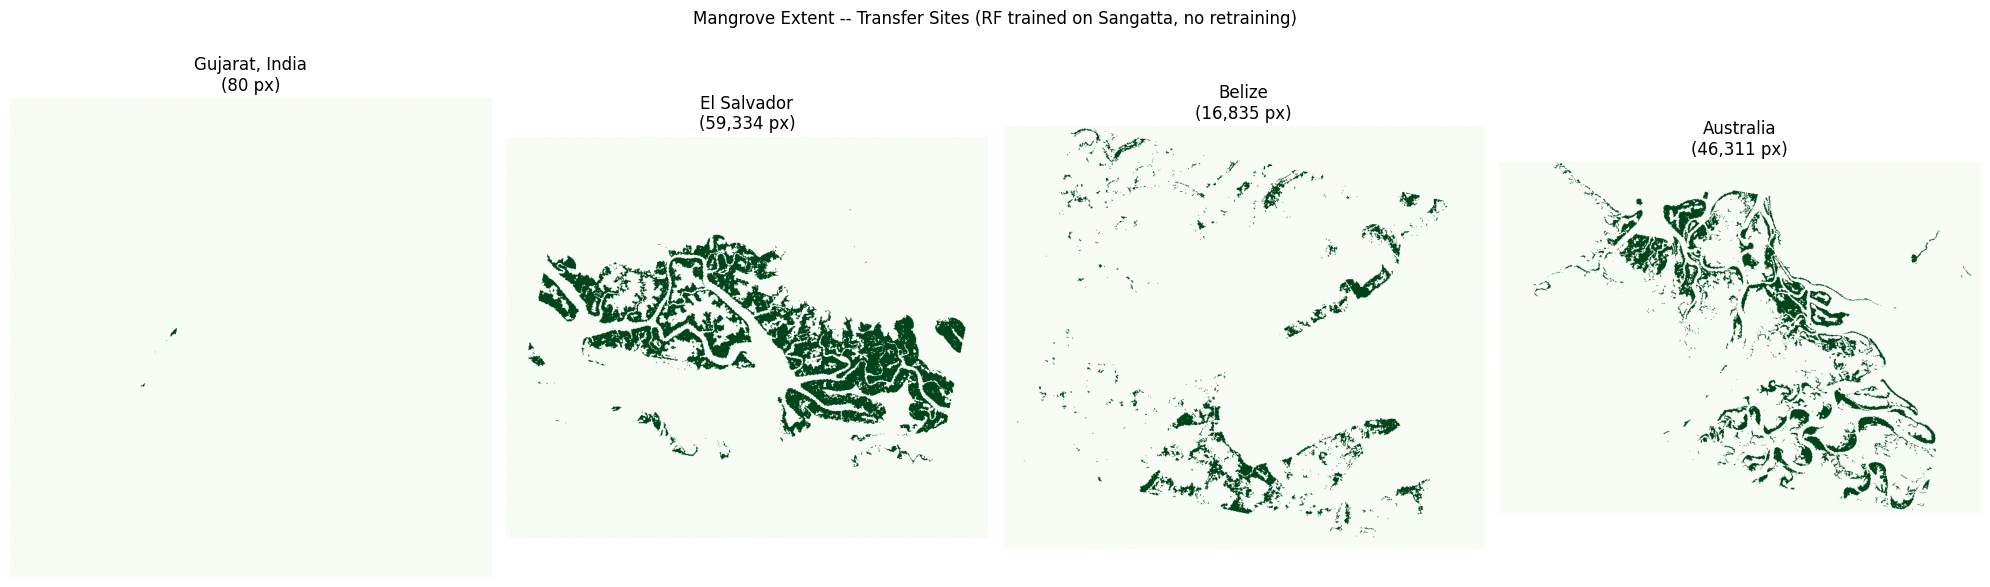

In [7]:
# ============================================================
# Load extent maps and plot side by side
# ============================================================
sites_to_plot = list(TRANSFER_SITES.items())
n_sites       = len(sites_to_plot)
fig, axes     = plt.subplots(1, n_sites, figsize=(5 * n_sites, 6))

for ax, (site, scene_id) in zip(axes, sites_to_plot):
    extent_path = DATA_PROC / f'extent_mangrove_{site}_{scene_id}.tif'
    if not extent_path.exists():
        ax.text(0.5, 0.5, f'{site}\nnot found',
                ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        continue
    with rasterio.open(extent_path) as src:
        n_px = int((src.read(1) == 1).sum())
        _img, _ext = reproject_raster_to_4326(src)
    ax.imshow(_img == 1, extent=_ext, origin='upper', cmap='Greens')
    ax.set_aspect('equal')
    ax.set_title(f'{SITE_LABELS[site]}\n({n_px:,} px)')
    format_map_axes(ax, fontsize=9)

plt.suptitle('Mangrove Extent -- Transfer Sites (RF trained on Sangatta, no retraining)', y=1.02)
plt.tight_layout()
plt.savefig(OUT_FIGURES / 'transferability_extent_maps.png', dpi=150, bbox_inches='tight')
plt.show()
